<a href="https://colab.research.google.com/github/COMP3608-Group-12/Project/blob/Dataset-3-Adding-Feature-Importance-Visualization-to-all-models/Group_12_Dataset_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 1: Importing Packages

In [1]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import imblearn

## STEP 2: Load & Understand Data

In [2]:
#MUST BE RUN inorder for file download to work
!pip install gdown

#Downloading dataset csv into runtime from google drive link
import gdown

#train dataset
url = "https://drive.google.com/uc?id=1WxiA2-DJuTOcykkqqTX-LECs9XltPHXt"
gdown.download(url, "train.csv", quiet=False)

#test dataset
url = "https://drive.google.com/uc?id=10qbFPqH3JYWfGmDSaal7IGzfGLb86HQV"
gdown.download(url, "test.csv", quiet=False)

#loading csv files into pandas dataframes
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1WxiA2-DJuTOcykkqqTX-LECs9XltPHXt
From (redirected): https://drive.google.com/uc?id=1WxiA2-DJuTOcykkqqTX-LECs9XltPHXt&confirm=t&uuid=4e3478af-11cf-49fa-996a-46f85f322597
To: /content/train.csv
100%|██████████| 351M/351M [00:06<00:00, 58.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=10qbFPqH3JYWfGmDSaal7IGzfGLb86HQV
From (redirected): https://drive.google.com/uc?id=10qbFPqH3JYWfGmDSaal7IGzfGLb86HQV&confirm=t&uuid=ea58f9d7-87f2-41aa-9aaa-9cca2ea45e79
To: /content/test.csv
100%|██████████| 150M/150M [00:02<00:00, 53.4MB/s]


In [3]:
#printing dataset information (how many rows, columns, datatype etc)
print(train_df.info())
print('----------------------------------------------------------')

#checking if any values are missing
print(train_df.isnull().sum())
print('----------------------------------------------------------')

# Show ONLY columns with missing values
print("Columns with missing values:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print('----------------------------------------------------------')

#Dropping rows with missing values, if any
train_df = train_df.dropna()

#Verifying that those rows have been dropped and there are no missing values
print("Total missing values after dropping:")
print(train_df.isnull().sum().sum())  # should be 0
print('----------------------------------------------------------')

#printing first 5 rows of data to ensure it correlates with datafile
print(train_df.head(5))
print('----------------------------------------------------------')

#checking how many transactions are fraudulent and how many are non-fraudulent
print(train_df['is_fraud'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

##Step 3: Data Preprocessing


###Step 3a: Feature Engineering



In [4]:
from sklearn.preprocessing import LabelEncoder

def build_features(df, fit_encoders=True, encoders=None):
    df = df.copy()

    # Converting fields with date & time from object to datetime
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])

    # Extracting individual features from trans_date_trans_time feature
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['dayofweek'] = df['trans_date_trans_time'].dt.dayofweek
    df['month'] = df['trans_date_trans_time'].dt.month

    # Converting DOB to age
    df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days

    # Label Encoding remaining columns of type object
    cat_cols = ['merchant', 'category', 'gender', 'state', 'job']

    if fit_encoders:
        encoders = {}
        for col in cat_cols:
            le = LabelEncoder()
            values = df[col].astype(str).tolist()
            values.append('unknown')
            le.fit(values)
            df[col + '_enc'] = le.transform(df[col].astype(str))
            encoders[col] = le
    else:
        for col in cat_cols:
            le = encoders[col]
            known = set(le.classes_)

            safe_values = np.where(
                df[col].astype(str).isin(known),
                df[col].astype(str),
                'unknown'
            )

            df[col + '_enc'] = le.transform(safe_values)

    return df, encoders

###Step 3b: Preprocessing on train data

In [5]:
# Apply feature engineering to test_df
train_df, encoders = build_features(train_df, fit_encoders=True)

# Drop unnecessary columns
train_df = train_df.drop(columns=[
    'Unnamed: 0', 'first', 'last', 'street',
    'trans_num', 'trans_date_trans_time', 'dob'
])

# Separate features and target
X = train_df.drop('is_fraud', axis=1)
y = train_df['is_fraud']

# Select only numerical columns for X
X = X.select_dtypes(include=['int64', 'float64'])

###Step 3c: Preprocessing on test data

In [6]:
# Apply feature engineering to test_df
test_df, _ = build_features(test_df, fit_encoders=False, encoders=encoders)

# Drop the same columns as in train_df
test_df = test_df.drop(columns=[
    'Unnamed: 0', 'first', 'last', 'street',
    'trans_num', 'trans_date_trans_time', 'dob'
])

# Separate features and target
X_test_final = test_df.drop('is_fraud', axis=1)
y_test_final = test_df['is_fraud']

# Select only numerical columns for X_test_final, consistent with how X was created
X_test_final = X_test_final.select_dtypes(include=['int64', 'float64'])

##Step 4a: Decision Tree Model using KFold Cross Validation

In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

#Decision Tree Model
model_dt = DecisionTreeClassifier(max_depth=10, random_state=42)

# StratifiedKFold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store results
dt_fold_results = []

all_y_true_dt = []
all_y_prob_dt = []
all_y_pred_dt = []

# Manual KFold Loop
for fold, (train_index, test_index) in enumerate(kf.split(X, y), 1):

    print(f"\n================== Fold {fold} ==================")

    # Split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # SMOTE on training data only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Train model
    model_dt.fit(X_train_resampled, y_train_resampled)

    # Predict on test data
    y_pred = model_dt.predict(X_test)
    y_prob = model_dt.predict_proba(X_test)[:, 1]

    all_y_true_dt.extend(y_test)
    all_y_prob_dt.extend(y_prob)
    all_y_pred_dt.extend(y_pred)

    #Performance metrics
    results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    results_df = pd.DataFrame({
        "Metric": list(results.keys()),
        "Value": [round(value, 4) for value in results.values()]
    })

    print(results_df)

    print(f"\n============================================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"\n============================================")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Appending results
    dt_fold_results.append(results)

# Taking average of all results
dt_results_df = pd.DataFrame(dt_fold_results)

avg_results_dt = dt_results_df.mean()
std_results_dt = dt_results_df.std()

final_results_dt = pd.DataFrame({
    "Metric": avg_results_dt.index,
    "Average Value": [round(val, 4) for val in avg_results_dt.values],
    "Std Dev": [round(val, 4) for val in std_results_dt.values]
})

print("\n================== AVERAGE PERFORMANCE ==================")
print(final_results_dt)


================== Fold 1 ==================
      Metric   Value
0   Accuracy  0.9567
1  Precision  0.1069
2     Recall  0.8802
3   F1 Score  0.1907
4    ROC-AUC  0.9537

Confusion Matrix:
[[123397   5520]
 [    90    661]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9993    0.9572    0.9778    128917
           1     0.1069    0.8802    0.1907       751

    accuracy                         0.9567    129668
   macro avg     0.5531    0.9187    0.5842    129668
weighted avg     0.9941    0.9567    0.9732    129668


================== Fold 2 ==================
      Metric   Value
0   Accuracy  0.9571
1  Precision  0.1110
2     Recall  0.9148
3   F1 Score  0.1980
4    ROC-AUC  0.9729

Confusion Matrix:
[[123414   5503]
 [    64    687]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9573    0.9779    128917
           1     0.1110    0.9148    0.1980       751

    accur

###STEP 4b: Feature Important Derived from Decision Tree

     Feature  Importance
         amt    0.839682
category_enc    0.120028
         age    0.013418
merchant_enc    0.006418
    city_pop    0.006343
  gender_enc    0.005341
   unix_time    0.004569
      cc_num    0.001143
         zip    0.000723
         lat    0.000609


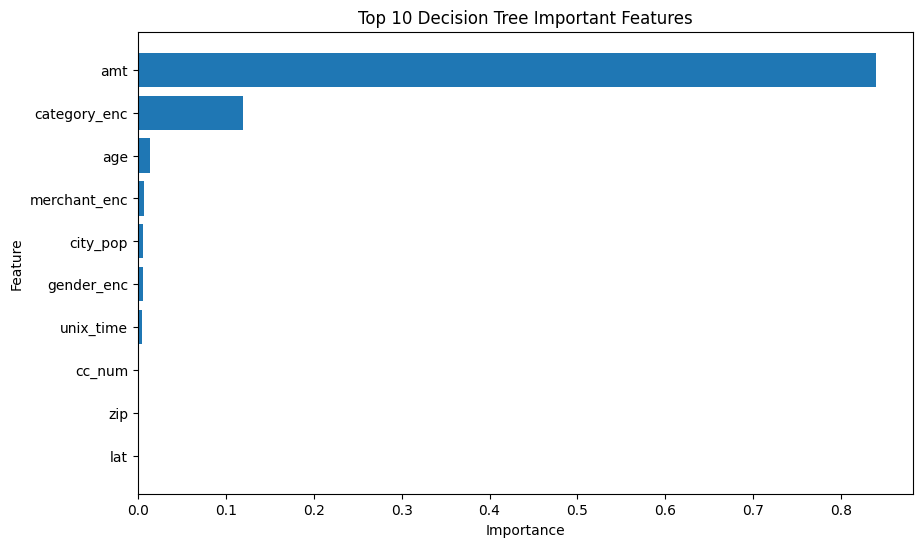

In [18]:
# Get feature importance values
importance_dt = model_dt.feature_importances_

# Creating dataframe
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance_dt
})

# Sorting in descending order
feature_importance_dt = feature_importance_dt.sort_values(
    by='Importance',
    ascending=False
)

# Printing top 10 features
print(feature_importance_dt.head(10).to_string(index=False))

# Plotting chart
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_dt['Feature'][:10],
    feature_importance_dt['Importance'][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Decision Tree Important Features")
plt.gca().invert_yaxis()
plt.show()

## Step 5: Deep Neural Network using K-Fold Cross Validation

In [9]:
#Runtime roughly around 50 mins

#Importing relavent packages
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


#Creating DNN Model
def create_dnn_model(input_dim):
  model = tf.keras.models.Sequential([
    Input(shape = (input_dim,)),

    layers.Dense(32, activation = 'relu'),
    layers.BatchNormalization(),                                                    #Normalize outputs

    layers.Dense(16, activation = 'relu'),
    layers.Dropout(0.2),                                                           #Prevents overfitting (20% dropoff)

    layers.Dense(8, activation = 'relu'),

    layers.Dense(1, activation = 'sigmoid')
  ])

  model.compile(
      optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
      loss = 'binary_crossentropy',
      metrics = [
          tf.keras.metrics.Precision(),
          tf.keras.metrics.Recall(),
          tf.keras.metrics.AUC()
      ]
  )
  return model

In [10]:
##K-Fold Setup, Training Model, Predicting and Metrics

#K-Fold setup
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

dnn_fold_results = []

all_y_true_dnn = []
all_y_prob_dnn = []
all_y_pred_dnn = []


#Manual K-Fold loop
for fold, (train_index, test_index) in enumerate(kf.split(X, y), 1):
    print(f"\n================== Fold {fold} ==================")

    # Split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    #Scaling Data
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    # SMOTE on training data only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


    #Training Model
    model = create_dnn_model(input_dim = X_train_resampled.shape[1])

    history = model.fit(
        X_train_resampled,
        y_train_resampled,
        epochs = 10,
        batch_size = 256,
        validation_split = 0.2,
        verbose = 1
    )

    #Predicting
    #y_prob = model.predict(X_test_scaled, verbose = 1).flatten()
    #y_pred = (y_prob > 0.5).astype(float)

    # ================== PREDICTIONS ==================

    y_prob = model.predict(X_test_scaled, verbose=1).flatten()

    # ================== THRESHOLD TUNING ==================

    # thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    # threshold_results = []

    # for threshold in thresholds:

    #     y_pred = (y_prob > threshold).astype(int)

    #     threshold_metrics = {
    #         'Threshold': threshold,
    #         'Accuracy': accuracy_score(y_test, y_pred),
    #         'Precision': precision_score(y_test, y_pred, zero_division=0),
    #         'Recall': recall_score(y_test, y_pred, zero_division=0),
    #         'F1 Score': f1_score(y_test, y_pred, zero_division=0)
    #     }

    #     threshold_results.append(threshold_metrics)

    # # Display threshold comparison table
    # threshold_results_df = pd.DataFrame(threshold_results)

    # print("\n================== THRESHOLD TUNING ==================")
    # print(threshold_results_df)

    # ================== SELECT FINAL THRESHOLD ==================

    threshold = 0.8

    y_pred = (y_prob > threshold).astype(int)

    all_y_true_dnn.extend(y_test)
    all_y_prob_dnn.extend(y_prob)
    all_y_pred_dnn.extend(y_pred)


    #Performance Metrics
    results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    results_df = pd.DataFrame({
        "Metric": list(results.keys()),
        "Value": [round(value, 4) for value in results.values()]
    })

    print(results_df)

    print("\n Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\n Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))


    #Appending all results
    dnn_fold_results.append(results)


#Tabulated Average of Results
dnn_results_df  = pd.DataFrame(dnn_fold_results)

avg_results_dnn = dnn_results_df.mean()
std_results_dnn = dnn_results_df.std()

final_results_dnn = pd.DataFrame({
    "Metric": avg_results_dnn.index,
    "Average Value": [round(val, 4) for val in avg_results_dnn.values],
    "Std Dev": [round(val, 4) for val in std_results_dnn.values],
})

print("\n================== AVERAGE PERFORMANCE ==================")
print(final_results_dnn.to_string(index=False))



================== Fold 1 ==================
Epoch 1/10
7252/7252 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - auc: 0.9589 - loss: 0.2281 - precision: 0.9556 - recall: 0.8170 - val_auc: 0.0000e+00 - val_loss: 0.2192 - val_precision: 1.0000 - val_recall: 0.8949
Epoch 2/10
7252/7252 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - auc: 0.9751 - loss: 0.1796 - precision: 0.9485 - recall: 0.8739 - val_auc: 0.0000e+00 - val_loss: 0.1789 - val_precision: 1.0000 - val_recall: 0.9236
Epoch 3/10
7252/7252 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - auc: 0.9779 - loss: 0.1684 - precision: 0.9475 - recall: 0.8841 - val_auc: 0.0000e+00 - val_loss: 0.1270 - val_precision: 1.0000 - val_recall: 0.9456
Epoch 4/10
7252/7252 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - auc: 0.9793 - loss: 0.1623 - precision: 0.9500 - recall: 0.8879 - val_auc: 0.0000e+00 - val_loss: 0.1145 - val_precision: 1.0000 - val_recall: 0.9529
Epoch 5/10
7252/7252 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - auc: 0.9801 - loss: 0.1589 - precision: 0.9527 - recall: 0.8899 - val

## Step 6: Logistic Regression with K Fold Cross Validation

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

#Logistic Regression Model
model_lr = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)

# StratifiedKFold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store results
lr_fold_results = []

all_y_true_lr = []
all_y_prob_lr = []
all_y_pred_lr = []

# Manual KFold Loop
for fold, (train_index, test_index) in enumerate(kf.split(X, y), 1):

    print(f"\n================== Fold {fold} ==================")

    # Split
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    #Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # SMOTE on training data only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # Train model
    model_lr.fit(X_train_resampled, y_train_resampled)

    # Predict on test data
    y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]

    #The following code was executed in order to choose the best possible threshold
    # ================== THRESHOLD TUNING ==================

    # thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    # threshold_results = []

    # for threshold in thresholds:

    #     y_pred = (y_prob > threshold).astype(int)

    #     threshold_metrics = {
    #         'Threshold': threshold,
    #         'Accuracy': accuracy_score(y_test, y_pred),
    #         'Precision': precision_score(y_test, y_pred, zero_division=0),
    #         'Recall': recall_score(y_test, y_pred, zero_division=0),
    #         'F1 Score': f1_score(y_test, y_pred, zero_division=0)
    #     }

    #     threshold_results.append(threshold_metrics)

    # # Display threshold comparison table
    # threshold_results_df = pd.DataFrame(threshold_results)

    # print("\n================== THRESHOLD TUNING ==================")
    # print(threshold_results_df)

    # ================== SELECT FINAL THRESHOLD ==================

    # The primary goal is to catch as many fraudulent transactions as possible
    # (high recall) to minimize financial loss, even if it means wrongly
    # flagging some legitimate transactions (lower precision).
    # Therefore, recall was considered more important than maximizing precision alone.
    # Threshold 0.6 provided a stronger balance between fraud detection capability and false positive reduction,
    # achieving high recall while still improving precision compared to lower thresholds.

    threshold = 0.6

    y_pred = (y_prob > threshold).astype(int)


    all_y_true_lr.extend(y_test)
    all_y_prob_lr.extend(y_prob)
    all_y_pred_lr.extend(y_pred)

    #Performance metrics
    results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    results_df = pd.DataFrame({
        "Metric": list(results.keys()),
        "Value": [round(value, 4) for value in results.values()]
    })

    print(results_df)

    print(f"\n============================================")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"\n============================================")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Appending results
    lr_fold_results.append(results)

# Taking average of all results
lr_results_df = pd.DataFrame(lr_fold_results)

avg_results_lr = lr_results_df.mean()
std_results_lr = lr_results_df.std()

final_results_lr = pd.DataFrame({
    "Metric": avg_results_lr.index,
    "Average Value": [round(val, 4) for val in avg_results_lr.values],
    "Std Dev": [round(val, 4) for val in std_results_lr.values]
})

print("\n================== AVERAGE PERFORMANCE ==================")
print(final_results_lr)



================== Fold 1 ==================
      Metric   Value
0   Accuracy  0.9719
1  Precision  0.1384
2     Recall  0.7364
3   F1 Score  0.2330
4    ROC-AUC  0.8454

Confusion Matrix:
[[125475   3442]
 [   198    553]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9984    0.9733    0.9857    128917
           1     0.1384    0.7364    0.2330       751

    accuracy                         0.9719    129668
   macro avg     0.5684    0.8548    0.6094    129668
weighted avg     0.9934    0.9719    0.9813    129668


================== Fold 2 ==================
      Metric   Value
0   Accuracy  0.9722
1  Precision  0.1452
2     Recall  0.7763
3   F1 Score  0.2446
4    ROC-AUC  0.8721

Confusion Matrix:
[[125484   3433]
 [   168    583]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9987    0.9734    0.9859    128917
           1     0.1452    0.7763    0.2446       751

    accur

##Step 7: Visualizing Results


###Step 7a: Table Showing Collated Average Performance Metrics & Standard Deviation


In [12]:
# Set Metric as index
dt_df = final_results_dt.set_index("Metric")
lr_df = final_results_lr.set_index("Metric")
dnn_df = final_results_dnn.set_index("Metric")

# Combining mean ± std dev
summary_table = pd.concat([
    (dt_df["Average Value"].round(4).astype(str) + " ± " + dt_df["Std Dev"].round(4).astype(str)).rename("Decision Tree"),
    (lr_df["Average Value"].round(4).astype(str) + " ± " + lr_df["Std Dev"].round(4).astype(str)).rename("Logistic Regression"),
    (dnn_df["Average Value"].round(4).astype(str) + " ± " + dnn_df["Std Dev"].round(4).astype(str)).rename("Deep Neural Network")
], axis=1).T

# Displaying data in styled table
styled_table = (
    summary_table.style
    .set_caption("Model Performance Comparison (Mean ± Std)")
    .set_table_styles([
        # Caption
        {'selector': 'caption',
         'props': [('font-size', '18px'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center'),
                   ('margin-bottom', '10px')]},

        # Header
        {'selector': 'th',
         'props': [('font-size', '15px'),
                   ('text-align', 'center'),
                   ('background-color', '#2c3e50'),
                   ('color', 'white'),
                   ('padding', '15px')]},

        # Data cells
        {'selector': 'td',
         'props': [('text-align', 'center'),
                   ('padding', '15px'),
                   ('border', '1px solid #ddd')]},

    ])
)

display(styled_table)

Metric,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Decision Tree,0.956 ± 0.0018,0.1065 ± 0.0034,0.8914 ± 0.0129,0.1903 ± 0.0055,0.9612 ± 0.0066
Logistic Regression,0.9717 ± 0.0006,0.1388 ± 0.0038,0.7458 ± 0.0228,0.2341 ± 0.0062,0.8546 ± 0.0125
Deep Neural Network,0.9906 ± 0.0047,0.3977 ± 0.0996,0.8488 ± 0.0206,0.5337 ± 0.0956,0.984 ± 0.0038


###Step 7b: Barchart Showing Average Performance Metrics for the 3 Models

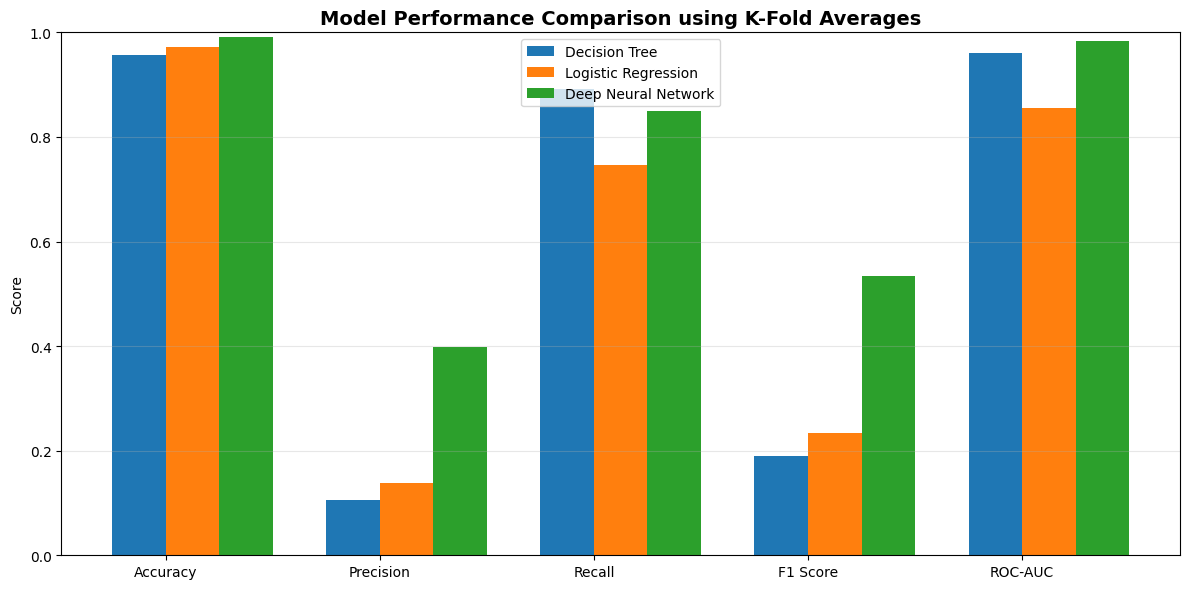

In [13]:
import matplotlib.pyplot as plt
import numpy as np

#Creating a summary of the average results of all three algorithms
results_summary = {
    "Decision Tree": final_results_dt.set_index("Metric")["Average Value"],
    "Logistic Regression": final_results_lr.set_index("Metric")["Average Value"],
    "Deep Neural Network": final_results_dnn.set_index("Metric")["Average Value"]
}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
models = list(results_summary.keys())

#Barchart
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12,6))

for i, model in enumerate(models):
    values = [results_summary[model][m] for m in metrics]
    plt.bar(x + i*width, values, width=width, label=model)

plt.xticks(x + width/2, metrics)
plt.ylabel("Score")
plt.title("Model Performance Comparison using K-Fold Averages", fontsize=14, fontweight='bold')
plt.ylim(0,1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

###Step 7c: AUC-ROC Curves using Aggregated K Fold Results

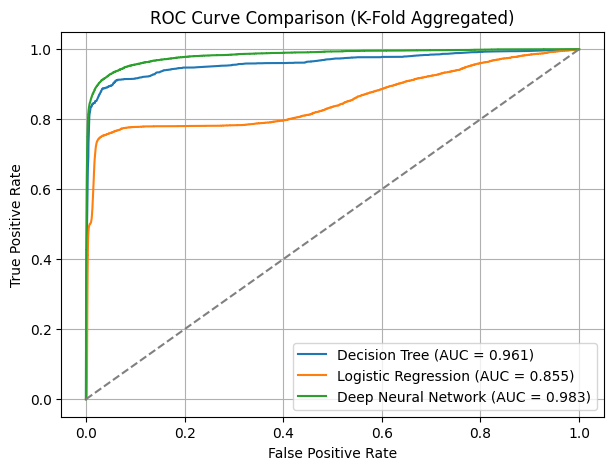

In [14]:
#AUC-ROC Curves for 3 algorithms
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(all_y_true_dt, all_y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(all_y_true_lr, all_y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")

# Deep Neural Network
fpr_dnn, tpr_dnn, _ = roc_curve(all_y_true_dnn, all_y_prob_dnn)
auc_dnn = auc(fpr_dnn, tpr_dnn)
plt.plot(fpr_dnn, tpr_dnn, label=f"Deep Neural Network (AUC = {auc_dnn:.3f})")

# Plotting curves

#Drawing baseline
plt.plot([0,1], [0,1], '--', color='gray')


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (K-Fold Aggregated)")
plt.legend()
plt.grid()

plt.show()

###Step 7d: Precision-Recall Curves


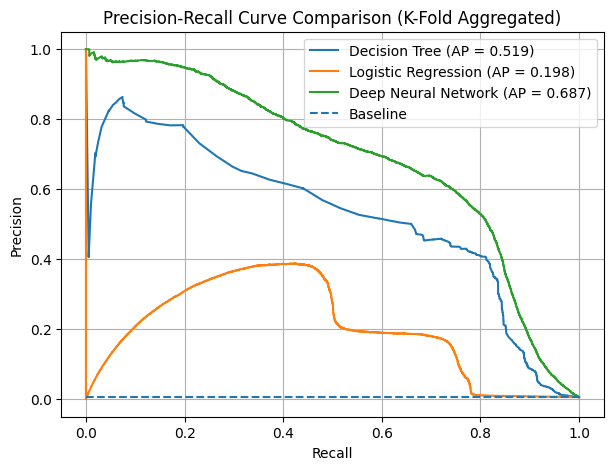

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Decision Tree
prec_dt, rec_dt, _ = precision_recall_curve(all_y_true_dt, all_y_prob_dt)
ap_dt = average_precision_score(all_y_true_dt, all_y_prob_dt)
plt.plot(rec_dt, prec_dt, label=f"Decision Tree (AP = {ap_dt:.3f})")

# Logistic Regression
prec_lr, rec_lr, _ = precision_recall_curve(all_y_true_lr, all_y_prob_lr)
ap_lr = average_precision_score(all_y_true_lr, all_y_prob_lr)
plt.plot(rec_lr, prec_lr, label=f"Logistic Regression (AP = {ap_lr:.3f})")

# Deep Neural Network
prec_dnn, rec_dnn, _ = precision_recall_curve(all_y_true_dnn, all_y_prob_dnn)
ap_dnn = average_precision_score(all_y_true_dnn, all_y_prob_dnn)
plt.plot(rec_dnn, prec_dnn, label=f"Deep Neural Network (AP = {ap_dnn:.3f})")

# Plotting curves

# Drawing baseline
baseline = sum(all_y_true_lr) / len(all_y_true_lr)
plt.hlines(baseline, 0, 1, linestyles='--', label='Baseline')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison (K-Fold Aggregated)")
plt.legend()
plt.grid()

plt.show()

###Step 7e: Confusion Matrices (Heatmaps)


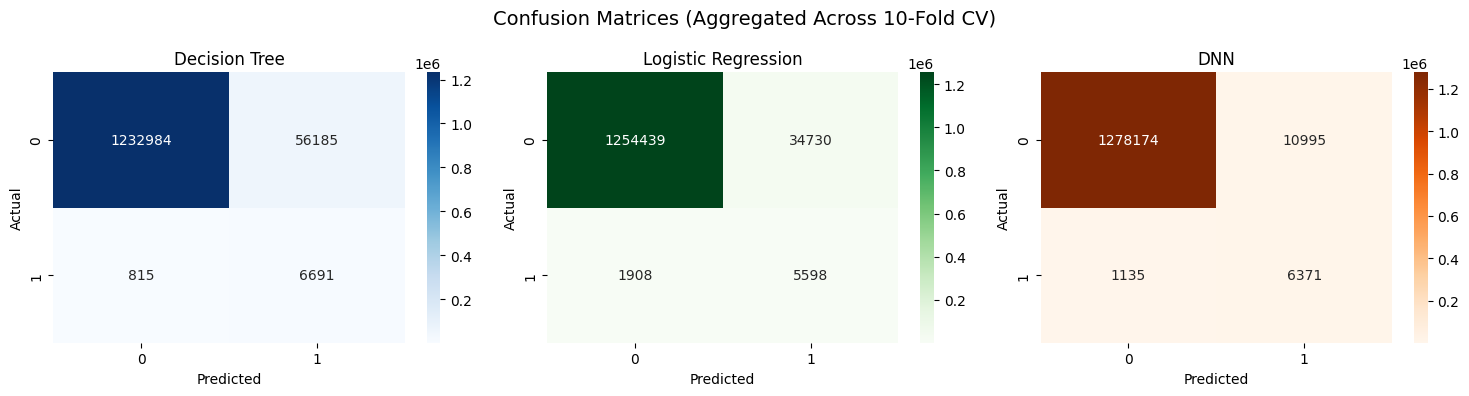

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_dt = confusion_matrix(all_y_true_dt, all_y_pred_dt)
cm_lr = confusion_matrix(all_y_true_lr, all_y_pred_lr)
cm_dnn = confusion_matrix(all_y_true_dnn, all_y_pred_dnn)

# Plot all in one figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Decision Tree")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Deep Neural Network
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title("DNN")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.suptitle("Confusion Matrices (Aggregated Across 10-Fold CV)", fontsize=14)
plt.tight_layout()
plt.show()

###Step 8: Final Evaluation of Best Performing Model on Test Data (Deep Neural Network)

In [17]:
# Scaling full training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X)
X_test_final_scaled = scaler.transform(X_test_final)

# Applying SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y)

# Creating final DNN model
final_model_dnn = create_dnn_model(input_dim = X_train_resampled.shape[1])

# Training final model on FULL training dataset
history_final = final_model_dnn.fit(
    X_train_resampled,
    y_train_resampled,
    epochs = 10,
    batch_size = 256,
    validation_split = 0.2,
    verbose = 1
)


print("\n================== FINAL TEST PERFORMANCE ==================")

# Predict probabilities
y_test_prob = final_model_dnn.predict(X_test_final_scaled, verbose = 1).flatten()

# Convert probabilities to predictions
threshold = 0.8 #Same best threshold used
y_test_pred = (y_test_prob > threshold).astype(int)

# Performance metrics
final_test_results_dnn = {
    'Accuracy': accuracy_score(y_test_final, y_test_pred),
    'Precision': precision_score(y_test_final, y_test_pred, zero_division=0),
    'Recall': recall_score(y_test_final, y_test_pred, zero_division=0),
    'F1 Score': f1_score(y_test_final, y_test_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test_final, y_test_prob)
}

# Results table
final_test_df_dnn = pd.DataFrame({
    "Metric": final_test_results_dnn.keys(),
    "Value": [round(v, 4) for v in final_test_results_dnn.values()]
})

print(final_test_df_dnn)

print(f"\n============================================")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\n============================================")
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Epoch 1/10
8058/8058 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - auc_10: 0.9604 - loss: 0.2234 - precision_10: 0.9506 - recall_10: 0.8256 - val_auc_10: 0.0000e+00 - val_loss: 0.2171 - val_precision_10: 1.0000 - val_recall_10: 0.9044
Epoch 2/10
8058/8058 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - auc_10: 0.9788 - loss: 0.1637 - precision_10: 0.9506 - recall_10: 0.8856 - val_auc_10: 0.0000e+00 - val_loss: 0.2101 - val_precision_10: 1.0000 - val_recall_10: 0.9093
Epoch 3/10
8058/8058 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - auc_10: 0.9809 - loss: 0.1552 - precision_10: 0.9511 - recall_10: 0.8938 - val_auc_10: 0.0000e+00 - val_loss: 0.2088 - val_precision_10: 1.0000 - val_recall_10: 0.9112
Epoch 4/10
8058/8058 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - auc_10: 0.9817 - loss: 0.1514 - precision_10: 0.9513 - recall_10: 0.8981 - val_auc_10: 0.0000e+00 - val_loss: 0.1924 - val_precision_10: 1.0000 - val_recall_10: 0.9187
Epoch 5/10
8058/8058 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - auc_10: 0.9824 - loss: 0.1483 - precision_1